2024년 경주 발전량 예측모델

train 데이터 범위: 2020년 ~ 2022년 (3년)

valid 데이터 범위: 2023년 (1년)

test 데이터 범위: 2024년(1년, 실제 예측)

valid와 test의 날씨 데이터는 모두 하루전 예보된 데이터로, 정보누수가 없도록 했습니다.

예시: valid 데이터의 2023년 1월 2일 날씨 정보는 2023년 1월 1일 15시 이전에 발령된 기상 예보

In [ ]:
from . import DataLoad, preprocess
#wtgs는 train의 날씨와 센서데이터를 merge 한뒤 딕셔너리화 한 것
wtgs, test, target = DataLoad.DataLoad()

ImportError: attempted relative import with no known parent package

In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 전처리
wtgs_train, wtgs_valid, target_train, target_valid = preprocess.preprocessing(wtgs, target)

In [ ]:
# 센서 피쳐 예측용 데이터 스플릿
from . import feature_prediction
X_train, y_train = feature_prediction.train_target_split(wtgs_train)
X_valid, y_valid = feature_prediction.train_target_split(wtgs_valid)

In [5]:
# 센서 피쳐 예측
merged_X_train, merged_X_valid, merged_X_test = feature_prediction.feature_prediction(X_train, X_valid, y_train, y_valid, test)

Prediction wtg01 complete!
Prediction wtg02 complete!
Prediction wtg03 complete!
Prediction wtg04 complete!
Prediction wtg05 complete!
Prediction wtg06 complete!
Prediction wtg07 complete!
Prediction wtg08 complete!
Prediction wtg09 complete!
All_data_merged


In [6]:
models = feature_prediction.models

In [ ]:
#데이터 24시간 단위로 쪼개고, 터빈 데이터들 하나로 합쳐서 텐서화
#X_train 텐서의 shape
# B: 일 수
# N: 터빈 수
# T: 하루단위 시간 수
# F: 피쳐 수
# (1096, 9, 24, 31)

from . import to_tensor
X_tensor_train, X_tensor_valid, y_tensor_train, y_tensor_valid, X_tensor_test = to_tensor.to_tensor(merged_X_train, merged_X_valid, target_train, target_valid, merged_X_test)

X_train tensor shape: torch.Size([1096, 9, 24, 33])
X_valid tensor shape: torch.Size([365, 9, 24, 33])
y_train tensor shape: torch.Size([1096, 24, 1])
y_valid tensor shape: torch.Size([365, 24, 1])
test_tensor shape: torch.Size([366, 9, 24, 33])


In [8]:
X_tensor_train = X_tensor_train.to(device)
X_tensor_valid = X_tensor_valid.to(device)
y_tensor_train = y_tensor_train.to(device)
y_tensor_valid = y_tensor_valid.to(device)
X_tensor_test = X_tensor_test.to(device)

In [ ]:
from . import 경주Model
import torch.nn as nn

#모델의 위도와 경도를 기반으로 haversine 공식 기반으로 거리를 구한 뒤
#1KM 이내에 있는 터빈을 엣지로 연결할 수 있게 인접행렬을 만들었습니다. (Wake Effect가 1km 이내에서 자주 일어날 것이라고 가정)

#모델은 T축에 대해 Attention 입력(24시간에서의 중요도, Temporal Attention)
#N축에 대해 Attention Score을 구해 인접행렬에 곱해서 Weighted Adjacency matrix 생성 (Spatial Attention)
#이후 temporal attention 적용된 데이터와 Weighted Adjacency matrix으로 GCN 레이어 적용(GCN Layer)
#GCN 적용된 데이터를 lstm에 넣고, 출력층에서 N축에 대해 aggregation(mean) (lstmGCN)

latitudes = 경주Model.latitudes
longitudes = 경주Model.longitudes

model = 경주Model.FullModel(latitudes, longitudes, X_tensor_train)
model = model.to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0059, weight_decay=0.0015) #모델의 loss가 한값에 고정되어 나오면 lr을 조금씩 수정해주세요
early_stopping = 경주Model.EarlyStopping(patience= 40, verbose= True, delta = 0.0001)


경주Model.train_loop(model= model,
                   criterion= criterion,
                   optimizer= optimizer,
                   num_epochs= 500,
                   early_stopping= early_stopping,
                   input_tensor= X_tensor_train,
                   valid_tensor= X_tensor_valid,
                   tg = y_tensor_train,
                   vt = y_tensor_valid)

c:\Users\user\Desktop\Repository\풍력발전량예측\경주_모델\경주Model.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lat = torch.tensor(latitudes).float() * torch.pi / 180
c:\Users\user\Desktop\Repository\풍력발전량예측\경주_모델\경주Model.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lon = torch.tensor(longitudes).float() * torch.pi / 180


Epoch 0, Train Loss: 0.256631, Validation Loss: 0.2356
EarlyStopping counter: 1/30
Epoch 1, Train Loss: 0.247159, Validation Loss: 0.2370
Epoch 2, Train Loss: 0.246305, Validation Loss: 0.2331
Epoch 3, Train Loss: 0.243065, Validation Loss: 0.2275
Epoch 4, Train Loss: 0.239166, Validation Loss: 0.2171
Epoch 5, Train Loss: 0.228537, Validation Loss: 0.2087
Epoch 6, Train Loss: 0.217368, Validation Loss: 0.1960
EarlyStopping counter: 1/30
Epoch 7, Train Loss: 0.203938, Validation Loss: 0.1985
EarlyStopping counter: 2/30
Epoch 8, Train Loss: 0.201887, Validation Loss: 0.2012
Epoch 9, Train Loss: 0.205192, Validation Loss: 0.1844
Epoch 10, Train Loss: 0.197582, Validation Loss: 0.1824
Epoch 11, Train Loss: 0.198632, Validation Loss: 0.1811
EarlyStopping counter: 1/30
Epoch 12, Train Loss: 0.192102, Validation Loss: 0.1899
EarlyStopping counter: 2/30
Epoch 13, Train Loss: 0.195986, Validation Loss: 0.1858
Epoch 14, Train Loss: 0.192778, Validation Loss: 0.1757
Epoch 15, Train Loss: 0.185860

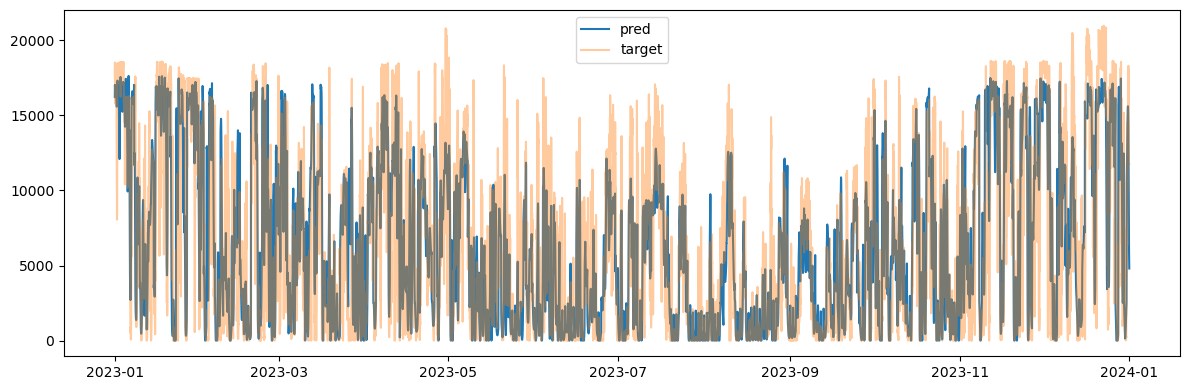

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#Validation용 2023년 예측 및 시각화

model.eval()
with torch.no_grad():
    predictions, _  = model(X_tensor_valid)
    predictions_np = predictions.cpu().numpy() 

output = predictions_np
output = output.reshape(-1, 1)

output_inverse = to_tensor.target_scaler.inverse_transform(output)
output_inverse = output_inverse.reshape(-1, 1)

pred = pd.DataFrame(output_inverse, columns = ["pred"])


target2023 = target_valid
pred.index = wtgs_valid["wtg01"].index


plt.figure(figsize = (12,4))
plt.plot(pred.index, pred, label = "pred")
plt.plot(target2023.index, target2023, label = "target", alpha = 0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#대회 전용 오차
#발전용량으로 정규화한 mae

#실제 센서데이터 사용시 NMAE 3~4 (사용 불가능. 2024년의 센서데이터가 없음)
#예측 센서데이터 사용시 NMAE 12~14(사용 가능)

def nmae(target, pred_target):
  mae = abs((target - pred_target))/20700
  nmae1 = mae.mean() * 100
  return nmae1

nmae1 = nmae(target2023, pred["pred"])
print(nmae1)

12.872892353861168

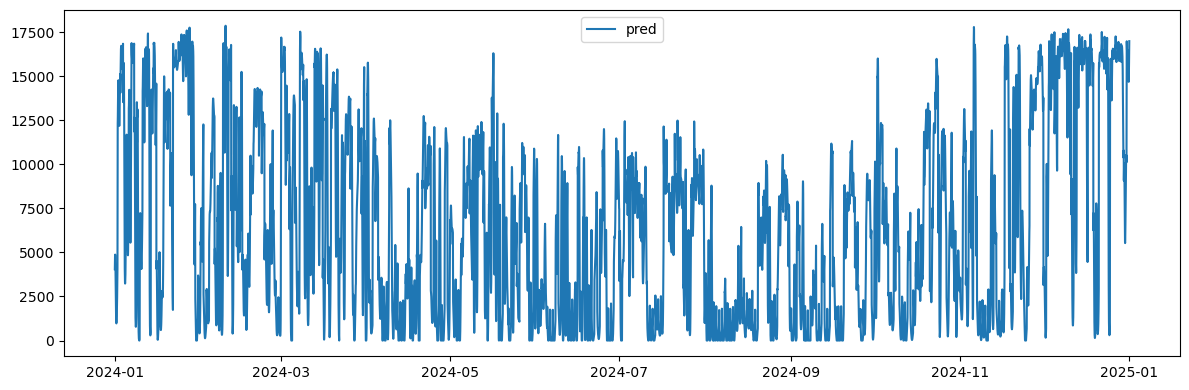

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#실제 예측(2024년도)

model.eval()
with torch.no_grad():
    predictions, _  = model(X_tensor_test) 
    predictions_np = predictions.cpu().numpy()

output = predictions_np
output = output.reshape(-1, 1)

output_inverse = to_tensor.target_scaler.inverse_transform(output)
output_inverse = output_inverse.reshape(-1, 1)

pred = pd.DataFrame(output_inverse, columns = ["pred"])


pred.index = test.index


plt.figure(figsize = (12,4))
plt.plot(pred.index, pred, label = "pred")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
pred.to_csv("./경주_모델/경주_예측/경주.csv")